# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [ ]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("data/bcn_noise_regre_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (12854, 22)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


## Reduce the number of columns

In [ ]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


<Axes: >

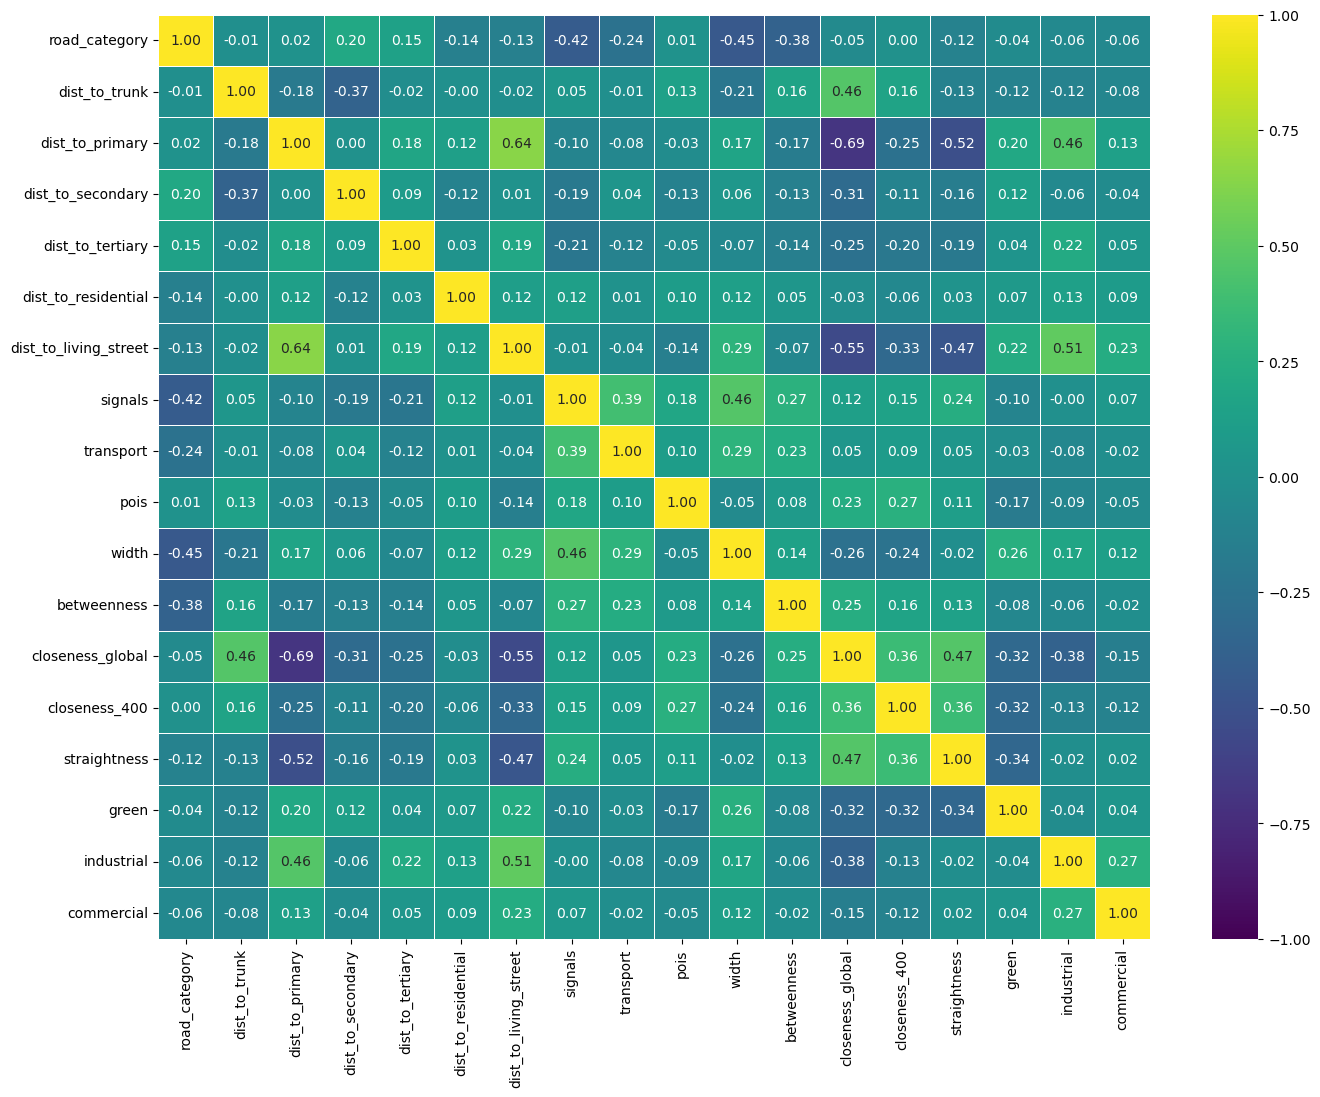

In [ ]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night']) #dropping y and non-relevant columns
plt.figure(figsize=(16, 12))  # width, height in inches
sns.heatmap(dataset_features.corr(), center=0, linewidths=0.5,
                 cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

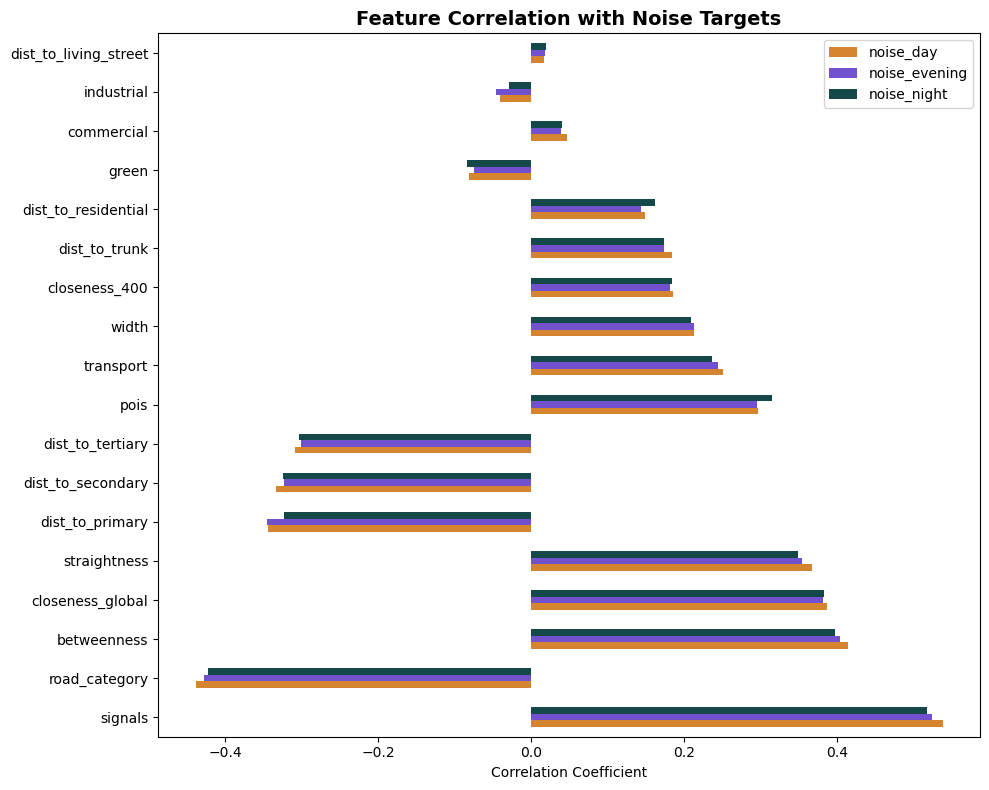

                       noise_day  noise_evening  noise_night
signals                 0.537599       0.523443     0.516671
betweenness             0.414573       0.403562     0.397532
closeness_global        0.387149       0.381789     0.382901
straightness            0.366926       0.353688     0.348063
pois                    0.295985       0.294901     0.315117
transport               0.250531       0.243716     0.236638
width                   0.213219       0.212702     0.209226
closeness_400           0.185180       0.180990     0.183888
dist_to_trunk           0.184695       0.174208     0.174089
dist_to_residential     0.149307       0.143347     0.162333
commercial              0.047160       0.038883     0.040231
dist_to_living_street   0.017460       0.018576     0.019450
industrial             -0.040769      -0.045528    -0.029033
green                  -0.081048      -0.074843    -0.083345
dist_to_tertiary       -0.307947      -0.300429    -0.302703
dist_to_secondary      -

In [ ]:
# Extract correlations with noise predictions
dataset_filtered = dataset.drop(columns=['road_id']) #dropping non-relevant columns
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

In [ ]:
dataset_pairs = dataset.drop(columns=['road_id', 'noise_evening', 'noise_night']) 

# Sample randomly
sample = dataset_pairs.sample(n=1000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)



In [ ]:
# other plots can be
# histograms
# paralel coordinates plot
# boxplots/violonplots for distributions

In [ ]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[55 50 65 45 60 70 75 35 40]

Unique values count: 9
